# Homework: Minimization

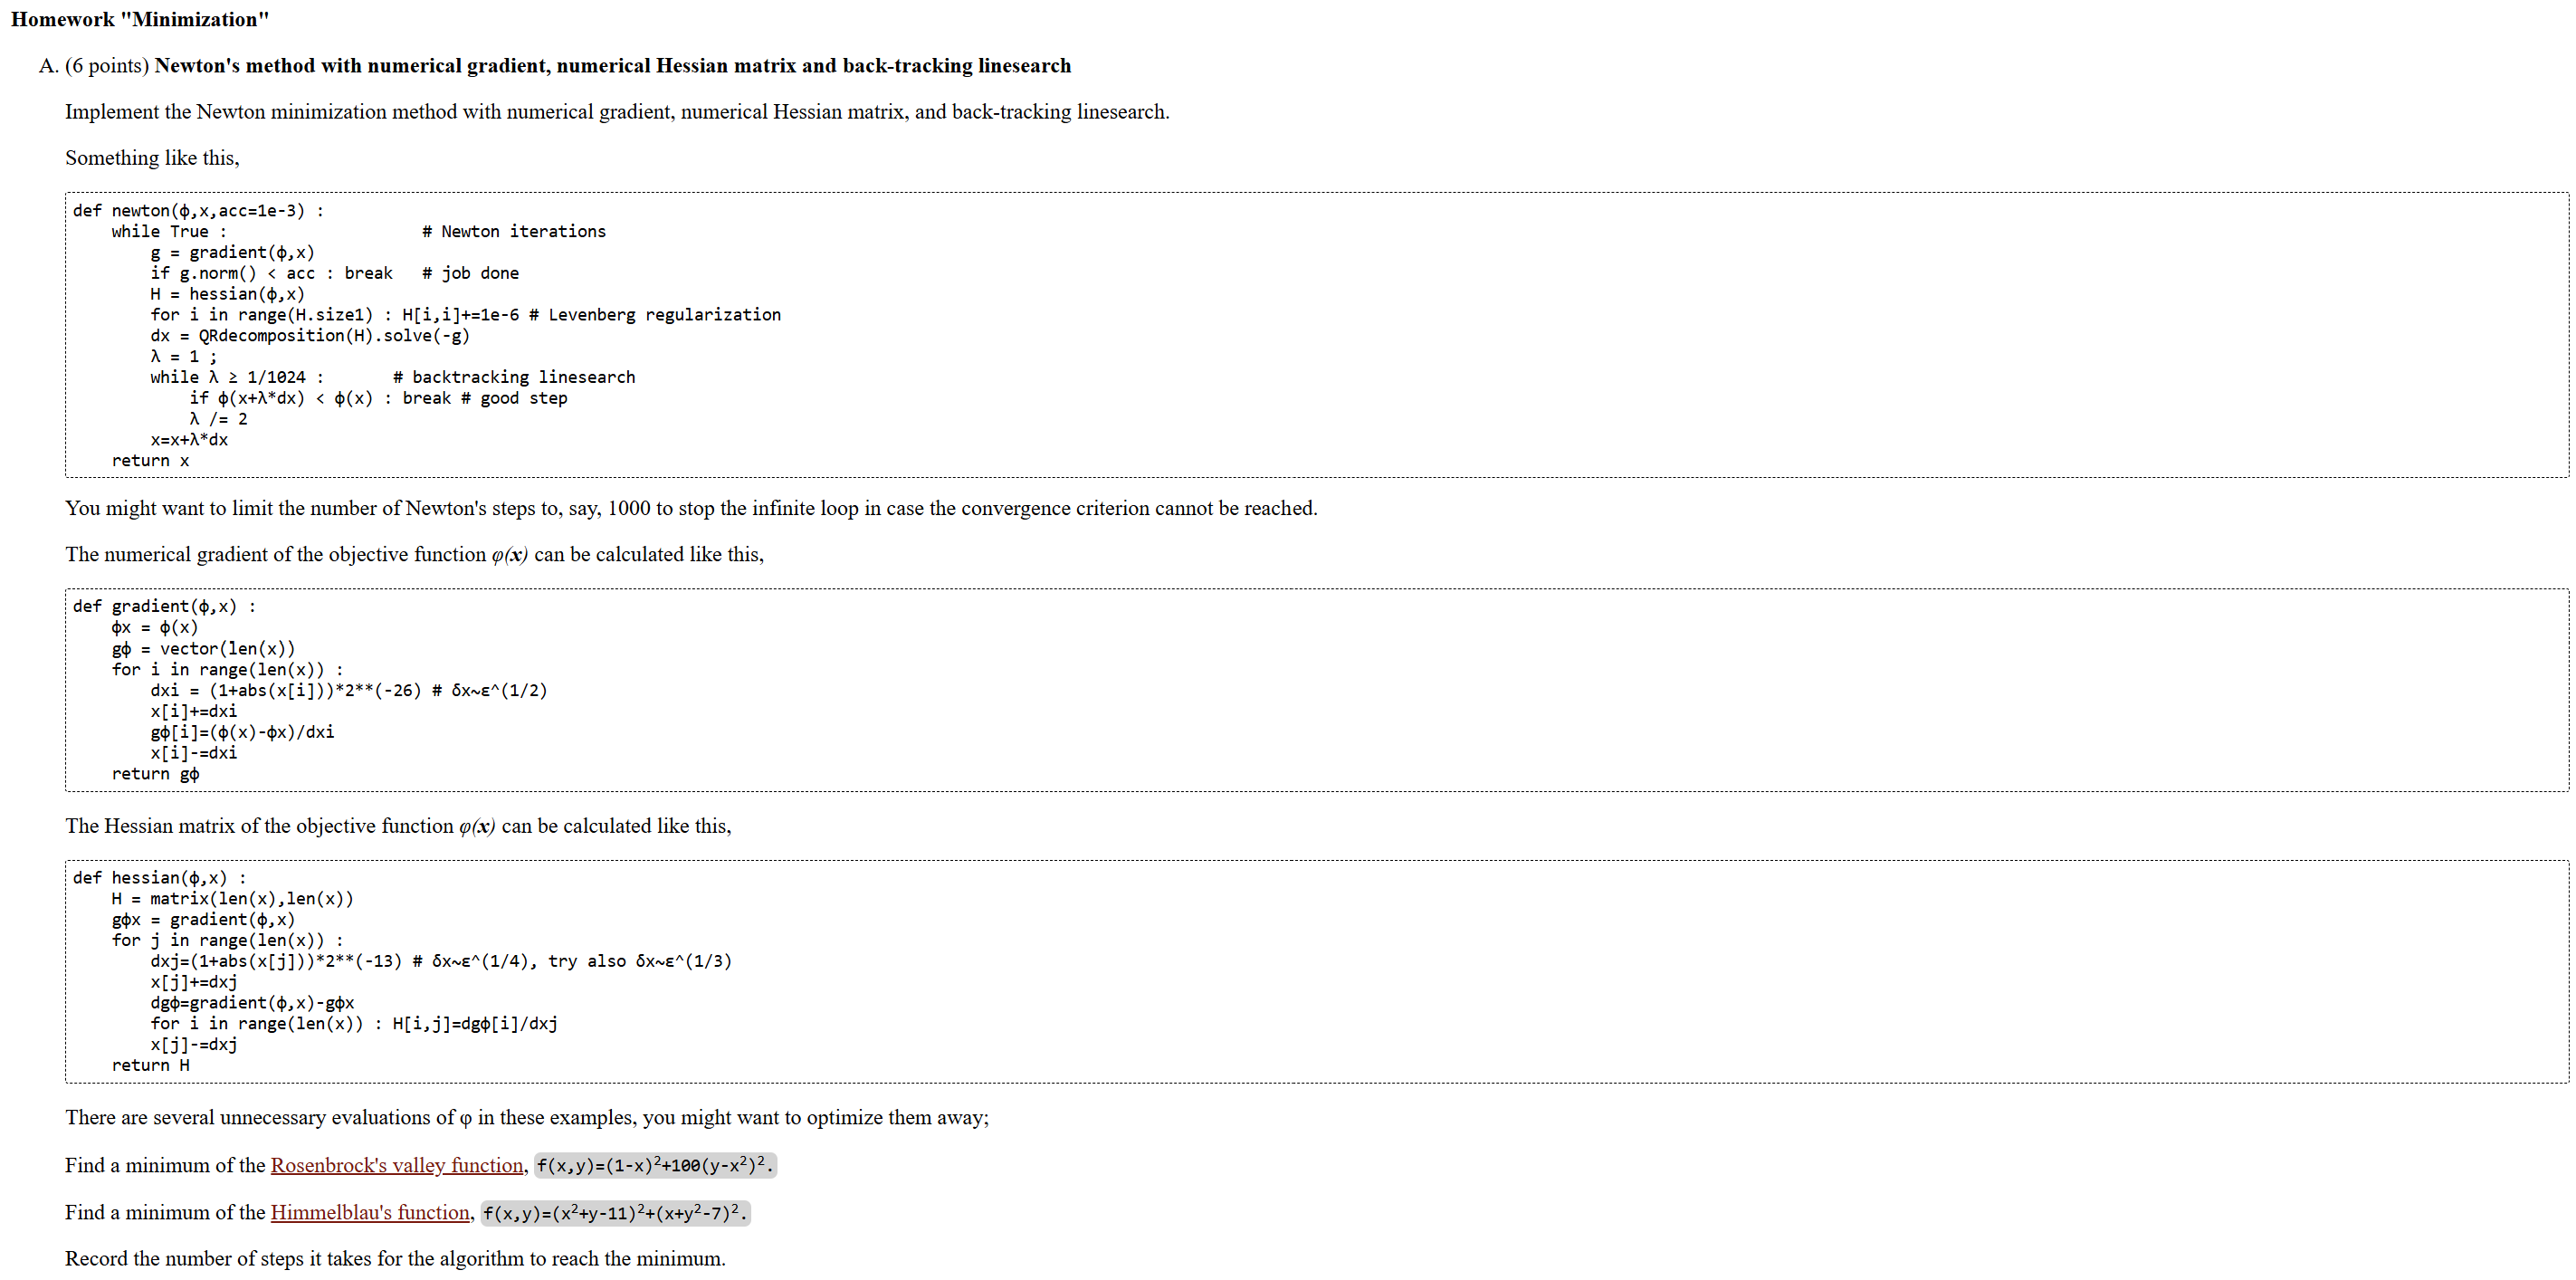

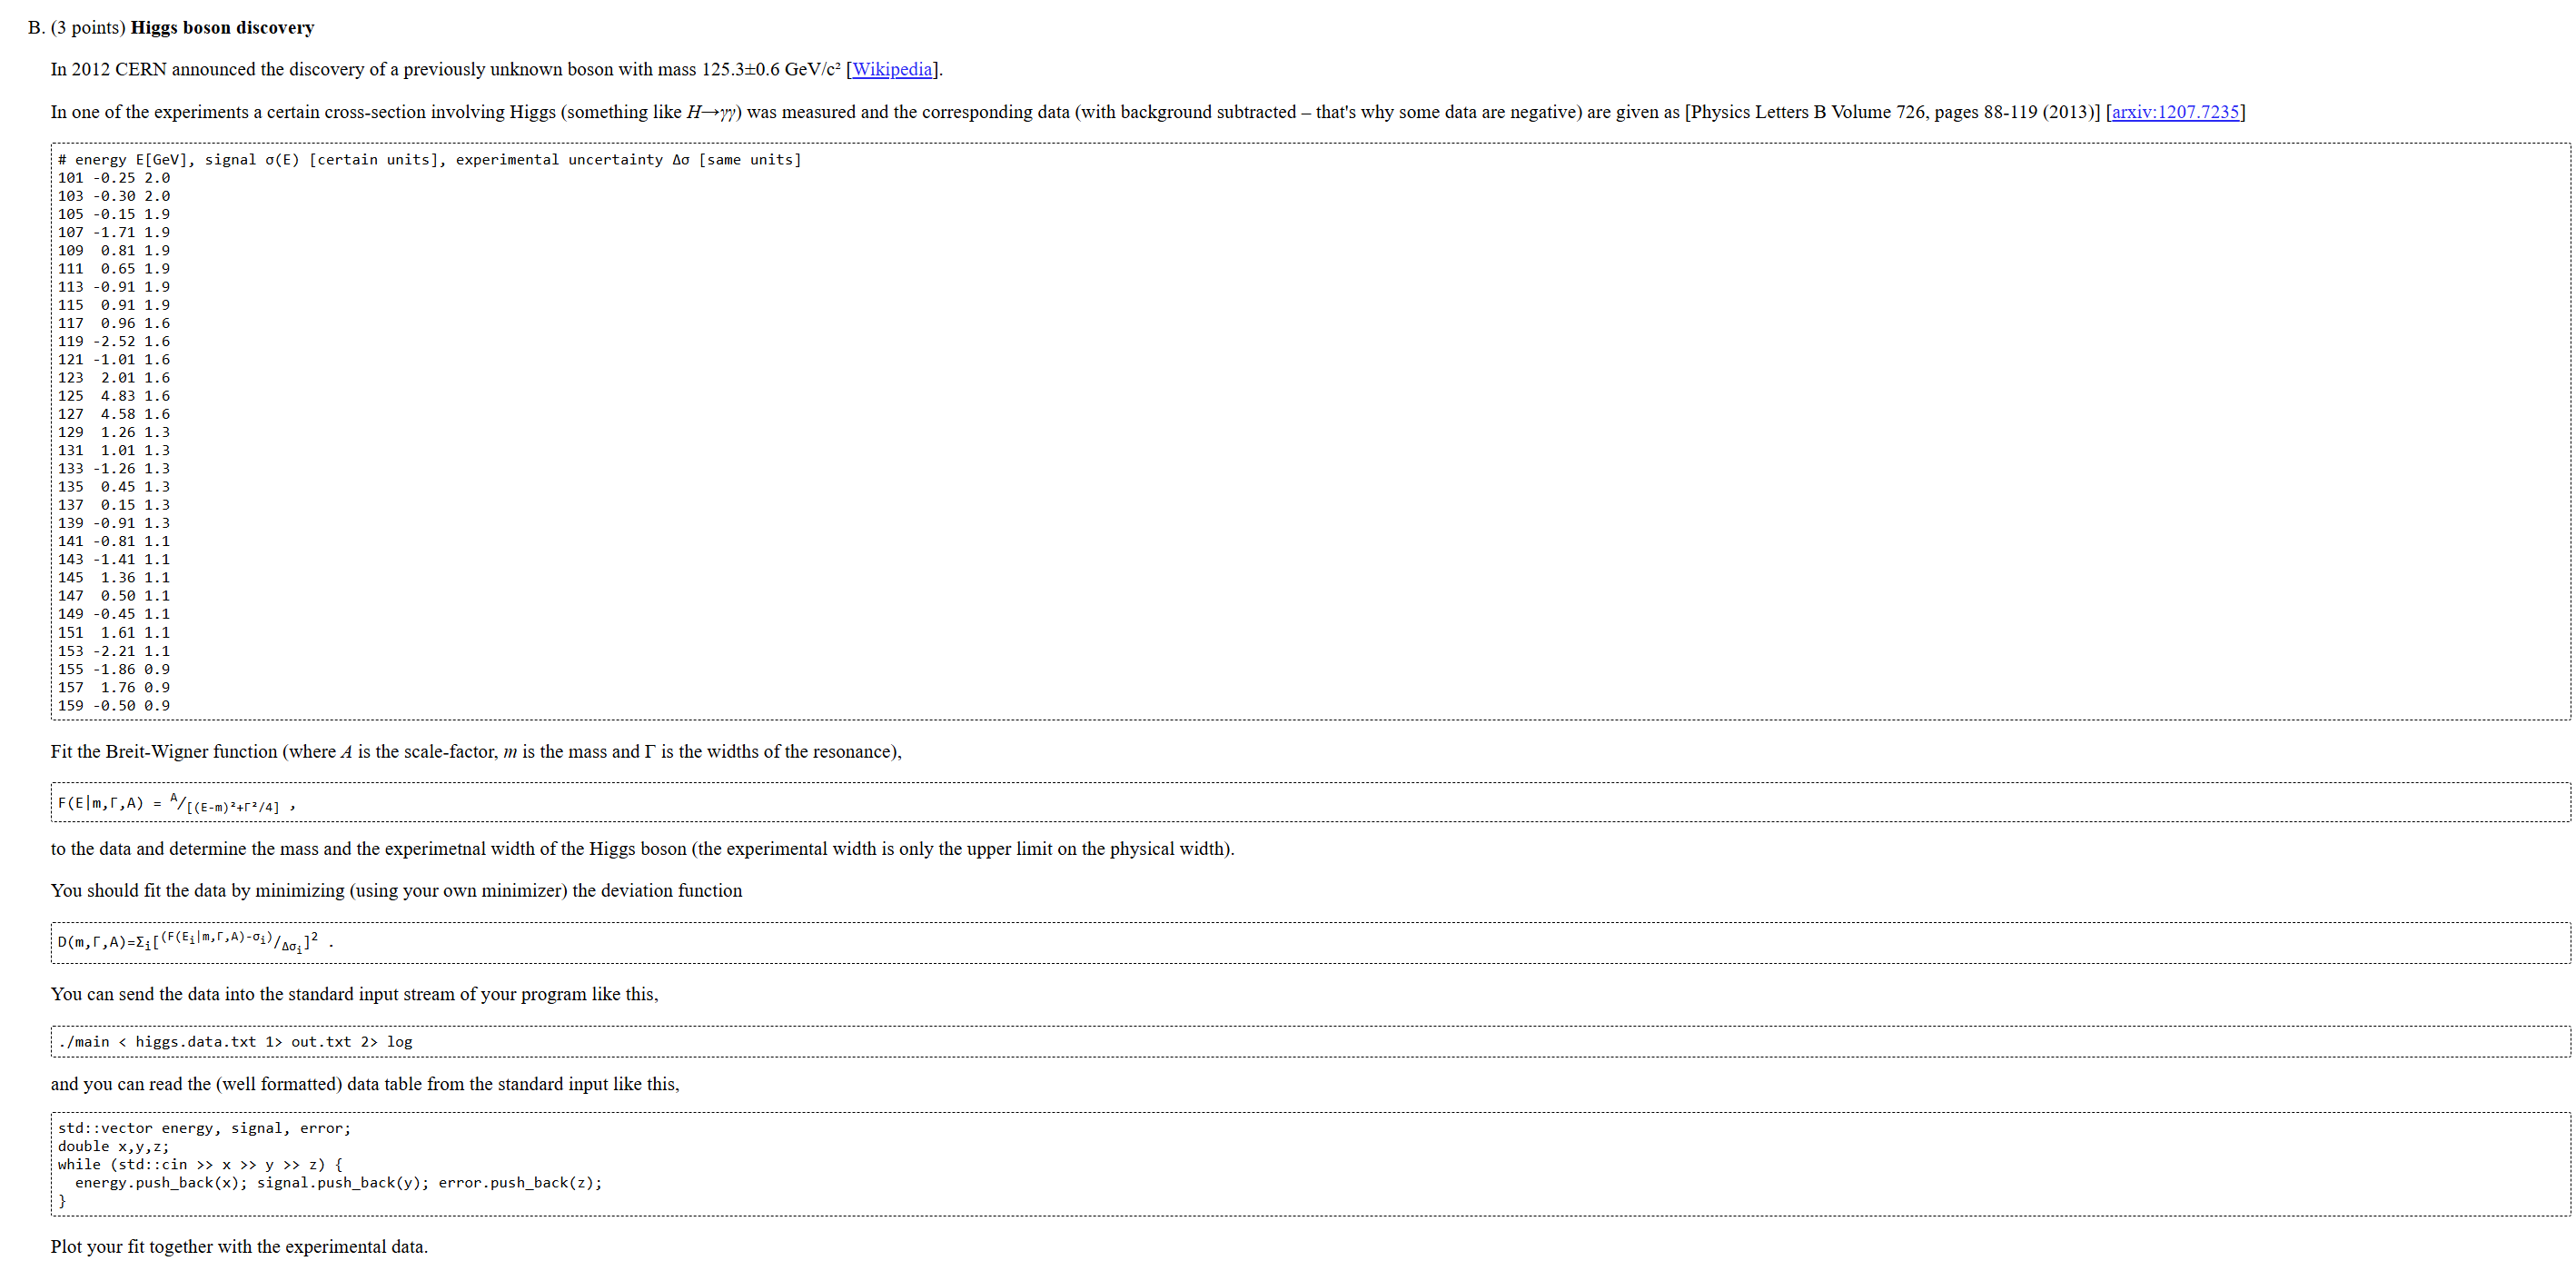

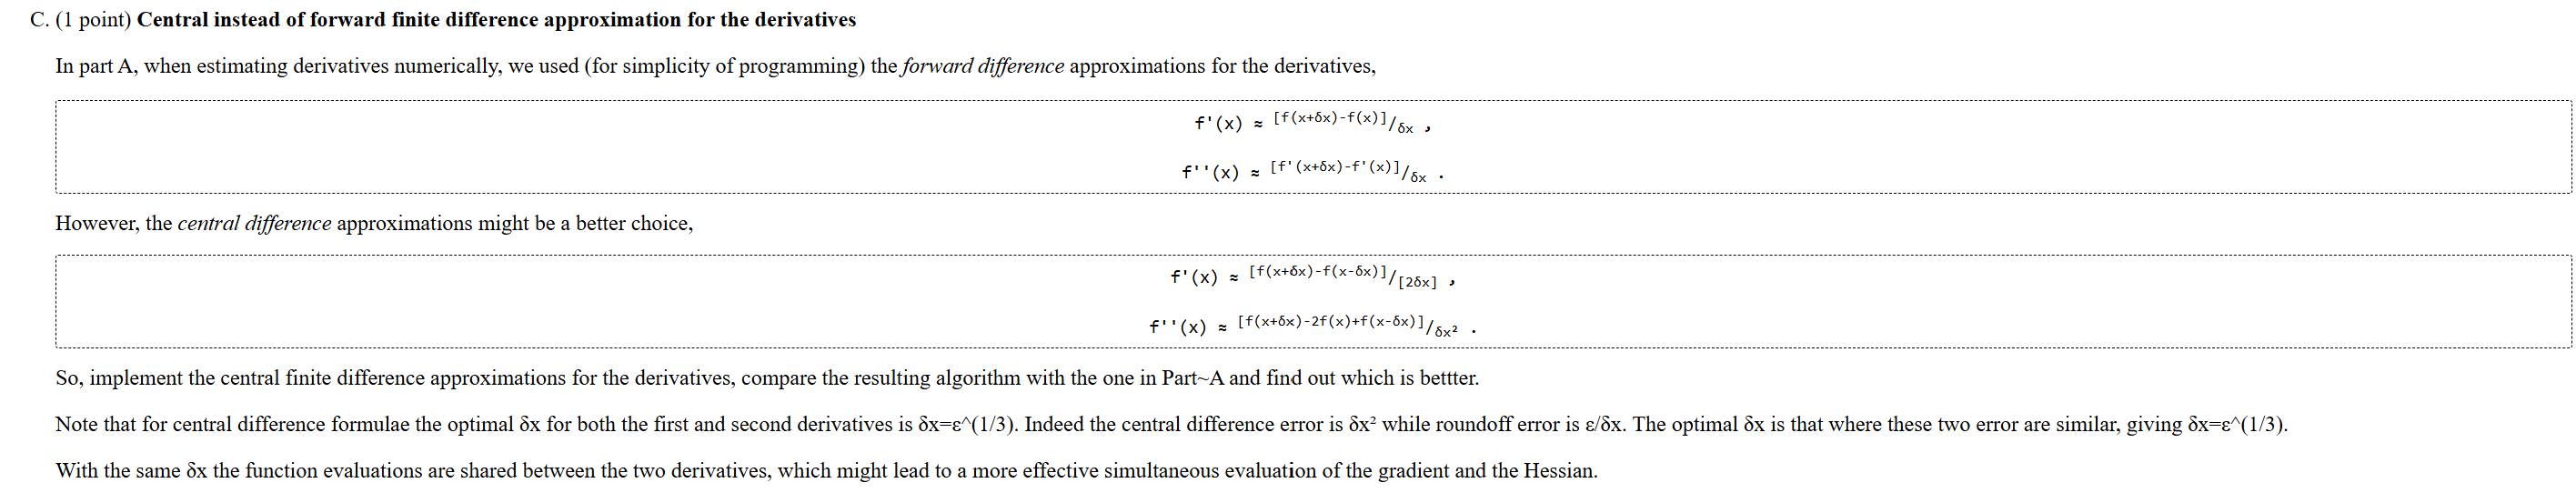


So in this homework, Newton's minimization method is implemented using numerical gradients, numerical Hessian matrices, and backtracking line-search.

The method is tested on the Rosenbrock function,

$$
f(x,y)=(1-x)^2+100(y-x^2)^2,
$$

and Himmelblau's function,

$$
f(x,y)=(x^2+y-11)^2+(x+y^2-7)^2.
$$

In [1]:
from pathlib import Path

Path("minimization.hpp").write_text(r'''
#pragma once

#include <cmath>
#include <functional>
#include <stdexcept>
#include <vector>
#include <algorithm>

using vec = std::vector<double>;
using mat = std::vector<vec>;
using func = std::function<double(const vec&)>;

inline vec operator+(const vec& a, const vec& b){
    vec r(a.size());
    for(size_t i=0;i<a.size();++i) r[i]=a[i]+b[i];
    return r;
}

inline vec operator-(const vec& a, const vec& b){
    vec r(a.size());
    for(size_t i=0;i<a.size();++i) r[i]=a[i]-b[i];
    return r;
}

inline vec operator*(double c, const vec& a){
    vec r(a.size());
    for(size_t i=0;i<a.size();++i) r[i]=c*a[i];
    return r;
}

inline double dot(const vec& a, const vec& b){
    double s=0;
    for(size_t i=0;i<a.size();++i) s += a[i]*b[i];
    return s;
}

inline double norm(const vec& a){
    return std::sqrt(dot(a,a));
}

inline vec solve_linear(mat A, vec b){
    int n = static_cast<int>(b.size());

    for(int k=0;k<n;k++){
        int pivot = k;
        for(int i=k+1;i<n;i++){
            if(std::abs(A[i][k]) > std::abs(A[pivot][k])) pivot = i;
        }

        if(std::abs(A[pivot][k]) < 1e-15){
            throw std::runtime_error("singular matrix");
        }

        std::swap(A[k], A[pivot]);
        std::swap(b[k], b[pivot]);

        double diag = A[k][k];
        for(int j=k;j<n;j++) A[k][j] /= diag;
        b[k] /= diag;

        for(int i=k+1;i<n;i++){
            double c = A[i][k];
            for(int j=k;j<n;j++) A[i][j] -= c*A[k][j];
            b[i] -= c*b[k];
        }
    }

    vec x(n);
    for(int i=n-1;i>=0;i--){
        double s = b[i];
        for(int j=i+1;j<n;j++) s -= A[i][j]*x[j];
        x[i] = s;
    }

    return x;
}

inline vec gradient_forward(const func& phi, const vec& x){
    int n = static_cast<int>(x.size());
    vec g(n), xp = x;
    double fx = phi(x);

    for(int i=0;i<n;i++){
        double dx = (1 + std::abs(x[i]))*std::pow(2.0,-26);
        xp[i] += dx;
        g[i] = (phi(xp)-fx)/dx;
        xp[i] = x[i];
    }

    return g;
}

inline mat hessian_forward(const func& phi, const vec& x){
    int n = static_cast<int>(x.size());
    mat H(n, vec(n));
    vec gx = gradient_forward(phi,x);
    vec xp = x;

    for(int j=0;j<n;j++){
        double dx = (1 + std::abs(x[j]))*std::pow(2.0,-13);
        xp[j] += dx;

        vec gp = gradient_forward(phi,xp);
        vec dg = gp - gx;

        for(int i=0;i<n;i++) H[i][j] = dg[i]/dx;

        xp[j] = x[j];
    }

    // Symmetrize the numerical Hessian
    for(int i=0;i<n;i++){
        for(int j=i+1;j<n;j++){
            double s = 0.5*(H[i][j] + H[j][i]);
            H[i][j] = s;
            H[j][i] = s;
        }
    }

    return H;
}

struct min_result{
    vec x;
    int iterations = 0;
    int backtracks = 0;
    bool converged = false;
    std::vector<vec> path;
};

inline min_result newton_minimize(const func& phi, vec x, double acc=1e-6, int max_iter=1000){
    min_result res;
    res.x = x;
    res.path.push_back(x);

    double fx = phi(x);

    for(int iter=0; iter<max_iter; iter++){
        vec g = gradient_forward(phi,x);

        if(norm(g) < acc){
            res.converged = true;
            break;
        }

        mat H = hessian_forward(phi,x);

        // Levenberg regularization
        for(size_t i=0;i<H.size();++i) H[i][i] += 1e-6;

        vec dx;
        try{
            dx = solve_linear(H, (-1.0)*g);
        }
        catch(...){
            dx = (-1.0)*g;
        }

        // If Newton direction is not downhill, use steepest descent
        if(dot(dx,g) > 0) dx = (-1.0)*g;

        double lambda = 1.0;

        while(lambda > 1.0/1024){
            vec z = x + lambda*dx;
            double fz = phi(z);

            if(fz < fx){
                x = z;
                fx = fz;
                break;
            }

            lambda /= 2;
            res.backtracks++;
        }

        res.iterations = iter + 1;
        res.path.push_back(x);

        if(lambda <= 1.0/1024 && norm(lambda*dx) < acc) break;
    }

    if(norm(gradient_forward(phi,x)) < acc) res.converged = true;

    res.x = x;
    return res;
}
''')

print("Wrote minimization.hpp")

Wrote minimization.hpp


In [2]:
from pathlib import Path

Path("min_A.cpp").write_text(r'''
#include "minimization.hpp"

#include <fstream>
#include <iomanip>
#include <iostream>
#include <string>
#include <vector>

void write_path(const std::string& filename, const std::vector<vec>& path){
    std::ofstream out(filename);
    out << std::setprecision(17);

    for(const auto& p : path){
        for(double v : p) out << v << " ";
        out << "\n";
    }
}

void print_result(const std::string& name, const min_result& r, const func& phi){
    vec g = gradient_forward(phi,r.x);

    std::cout << "\n" << name << "\n";
    std::cout << "  x = ";
    for(double v : r.x) std::cout << std::setw(17) << v << " ";
    std::cout << "\n";

    std::cout << "  f(x)        = " << phi(r.x) << "\n";
    std::cout << "  |grad f(x)| = " << norm(g) << "\n";
    std::cout << "  iterations  = " << r.iterations << "\n";
    std::cout << "  backtracks  = " << r.backtracks << "\n";
    std::cout << "  converged   = " << std::boolalpha << r.converged << "\n";
}

int main(){
    std::cout << std::setprecision(12);

    std::cout << "Task A: Newton minimization\n";
    std::cout << "===========================\n";

    func rosenbrock = [](const vec& x){
        return std::pow(1-x[0],2) + 100*std::pow(x[1]-x[0]*x[0],2);
    };

    func himmelblau = [](const vec& x){
        return std::pow(x[0]*x[0]+x[1]-11,2)
             + std::pow(x[0]+x[1]*x[1]-7,2);
    };

    auto rr = newton_minimize(rosenbrock, {-1.2,1.0}, 1e-6, 1000);

    print_result("Rosenbrock minimum", rr, rosenbrock);
    write_path("min_A_rosenbrock_path.data", rr.path);

    std::vector<vec> starts = {
        {2.5, 2.0},
        {-2.5, 3.0},
        {-4.0, -3.0},
        {4.0, -2.0}
    };

    std::ofstream roots("min_A_himmelblau_roots.data");
    roots << std::setprecision(17);

    std::ofstream paths("min_A_himmelblau_paths.data");
    paths << std::setprecision(17);

    for(size_t i=0;i<starts.size();++i){
        auto r = newton_minimize(himmelblau, starts[i], 1e-6, 1000);

        print_result("Himmelblau minimum " + std::to_string(i+1), r, himmelblau);

        for(double v : r.x) roots << v << " ";
        roots << "\n";

        for(const auto& p : r.path){
            for(double v : p) paths << v << " ";
            paths << "\n";
        }

        paths << "\n";
    }

    std::cout << "\nWrote min_A_rosenbrock_path.data\n";
    std::cout << "Wrote min_A_himmelblau_roots.data\n";
    std::cout << "Wrote min_A_himmelblau_paths.data\n";

    return 0;
}
''')

print("Wrote min_A.cpp")

Wrote min_A.cpp


In [3]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "min_A.cpp",
    "-o",
    "min_A"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./min_A"], text=True, capture_output=True, timeout=30)

    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task A: Newton minimization

Rosenbrock minimum
  x =    0.999990916844    0.999981819027 
  f(x)        = 8.25254632798e-11
  |grad f(x)| = 3.20233519494e-07
  iterations  = 23
  backtracks  = 6
  converged   = true

Himmelblau minimum 1
  x =     2.99999997181     1.99999999421 
  f(x)        = 3.32504861109e-14
  |grad f(x)| = 3.21634218542e-09
  iterations  = 5
  backtracks  = 0
  converged   = true

Himmelblau minimum 2
  x =    -2.80511811416     3.13131248793 
  f(x)        = 6.21103830448e-14
  |grad f(x)| = 3.44278554989e-08
  iterations  = 4
  backtracks  = 0
  converged   = true

Himmelblau minimum 3
  x =    -3.77931030033    -3.28318603805 
  f(x)        = 1.62575757316e-13
  |grad f(x)| = 1.63817406923e-08
  iterations  = 4
  backtracks  = 0
  converged   = true

Himmelblau minimum 4
  x =     3.58442830727    -1.84812654023 
  f(x)        = 6.28961973856e-14
  |grad f(x)| = 2.28959257175e-08
  iterations  = 4
  backtracks  = 0
  converg

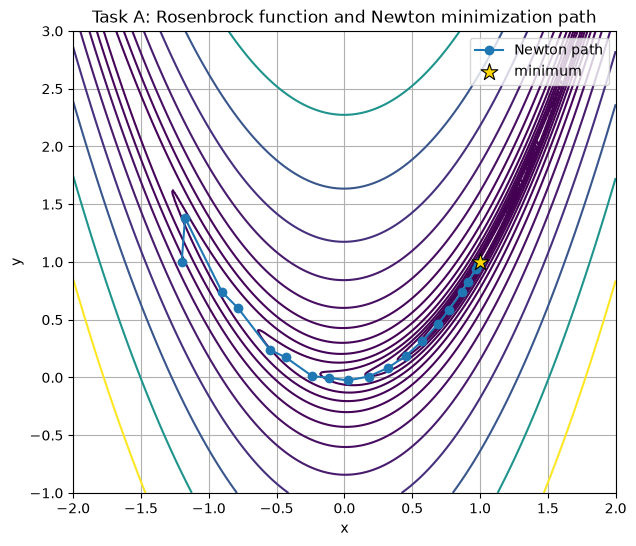

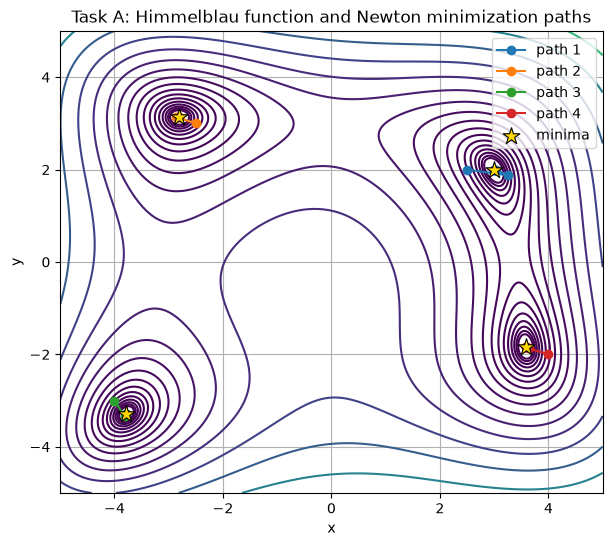

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- Rosenbrock plot ----------
rosen_path = np.loadtxt("min_A_rosenbrock_path.data")

x = np.linspace(-2.0, 2.0, 300)
y = np.linspace(-1.0, 3.0, 300)
X, Y = np.meshgrid(x, y)
Z = (1 - X)**2 + 100*(Y - X**2)**2

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 15))
plt.plot(rosen_path[:, 0], rosen_path[:, 1], marker="o", label="Newton path")
plt.scatter([1], [1], marker="*", s=160, color="gold",
            edgecolors="black", linewidths=0.8,
            label="minimum", zorder=5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Task A: Rosenbrock function and Newton minimization path")
plt.legend()
plt.grid(True)
plt.show()


# ---------- Himmelblau plot ----------
himmel_roots = np.loadtxt("min_A_himmelblau_roots.data")

x = np.linspace(-5.0, 5.0, 400)
y = np.linspace(-5.0, 5.0, 400)
X, Y = np.meshgrid(x, y)
Z = (X**2 + Y - 11)**2 + (X + Y**2 - 7)**2

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=np.logspace(0, 3, 18))

blocks = []
current = []

for line in Path("min_A_himmelblau_paths.data").read_text().splitlines():
    if line.strip():
        current.append([float(v) for v in line.split()])
    else:
        if current:
            blocks.append(np.array(current))
            current = []

if current:
    blocks.append(np.array(current))

for i, block in enumerate(blocks):
    plt.plot(block[:, 0], block[:, 1], marker="o", label=f"path {i+1}")

plt.scatter(himmel_roots[:, 0], himmel_roots[:, 1],
            marker="*", s=160, color="gold",
            edgecolors="black", linewidths=0.8,
            label="minima", zorder=5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Task A: Himmelblau function and Newton minimization paths")
plt.legend()
plt.grid(True)
plt.show()

## Task A conclusion

Newton's minimization method with numerical gradient, numerical Hessian and backtracking line-search was implemented and tested on the Rosenbrock and Himmelblau functions.

For the Rosenbrock function, the method converged to the known minimum close to $(1,1)$, with a very small function value and gradient norm. The contour plot shows that the method follows the curved valley towards the minimum.

For the Himmelblau function, different starting points were used, and the method converged to the four known minima of the function. This shows that the final minimum depends on the starting point, since Himmelblau's function has several local minima.

Overall, the method works as expected for both a narrow valley problem and a multi-minimum problem.

# Task B: Higgs boson Breit-Wigner fit

In this task, the Breit-Wigner function

$$
F(E;m,\Gamma,A)=\frac{A}{(E-m)^2+\Gamma^2/4}
$$

is fitted to the Higgs boson data by minimizing

$$
D(m,\Gamma,A)=\sum_i \left(\frac{F(E_i;m,\Gamma,A)-\sigma_i}{\Delta\sigma_i}\right)^2.
$$

The fit parameters are the resonance mass $m$, the width $\Gamma$, and the scale factor $A$.

In [5]:
from pathlib import Path

Path("higgs.data.txt").write_text("""101 -0.25 2.0
103 -0.30 2.0
105 -0.15 1.9
107 -1.71 1.9
109 0.81 1.9
111 0.65 1.9
113 -0.91 1.9
115 0.91 1.9
117 0.96 1.6
119 -2.52 1.6
121 -1.01 1.6
123 2.01 1.6
125 4.83 1.6
127 4.58 1.6
129 1.26 1.3
131 1.01 1.3
133 -1.26 1.3
135 0.45 1.3
137 0.15 1.3
139 -0.91 1.3
141 -0.81 1.1
143 -1.41 1.1
145 1.36 1.1
147 0.50 1.1
149 -0.45 1.1
151 1.61 1.1
153 -2.21 1.1
155 -1.86 0.9
157 1.76 0.9
159 -0.50 0.9
""")

print("Wrote higgs.data.txt")

Wrote higgs.data.txt


In [6]:
from pathlib import Path

Path("min_B.cpp").write_text(r'''
#include "minimization.hpp"

#include <cmath>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <vector>

struct point{
    double E;
    double y;
    double dy;
};

int main(){
    std::vector<point> data;

    double E, y, dy;
    while(std::cin >> E >> y >> dy){
        data.push_back({E,y,dy});
    }

    if(data.empty()){
        std::cerr << "No data read.\n";
        return 1;
    }

    auto breit_wigner = [](double E, double m, double Gamma, double A){
        return A/(std::pow(E-m,2) + Gamma*Gamma/4.0);
    };

    // Use transformed parameters:
    // p[0] = m, p[1] = log(Gamma), p[2] = log(A)
    // This keeps Gamma and A positive.
    func chi2 = [&](const vec& p){
        double m = p[0];
        double Gamma = std::exp(p[1]);
        double A = std::exp(p[2]);

        if(!std::isfinite(m) || !std::isfinite(Gamma) || !std::isfinite(A)){
            return 1e100;
        }

        // Soft safety bounds to avoid meaningless numerical steps.
        if(m < 100 || m > 160 || Gamma < 0.05 || Gamma > 30 || A < 1e-6 || A > 1e5){
            return 1e50 + std::pow(m-126,2);
        }

        double sum = 0.0;

        for(const auto& q : data){
            double fit = breit_wigner(q.E,m,Gamma,A);
            double r = (fit - q.y)/q.dy;
            sum += r*r;
        }

        return sum;
    };

    vec start = {126.0, std::log(2.0), std::log(10.0)};

    auto result = newton_minimize(chi2, start, 1e-5, 1000);

    double m = result.x[0];
    double Gamma = std::exp(result.x[1]);
    double A = std::exp(result.x[2]);

    std::cout << std::setprecision(12);

    std::cout << "Task B: Higgs boson Breit-Wigner fit\n";
    std::cout << "====================================\n\n";

    std::cout << "data points = " << data.size() << "\n";
    std::cout << "m      = " << m << " GeV\n";
    std::cout << "Gamma  = " << Gamma << " GeV\n";
    std::cout << "A      = " << A << "\n";
    std::cout << "chi2   = " << chi2(result.x) << "\n";
    std::cout << "iterations = " << result.iterations << "\n";
    std::cout << "backtracks = " << result.backtracks << "\n";
    std::cout << "converged  = " << std::boolalpha << result.converged << "\n";

    std::ofstream curve("min_B_fit_curve.data");
    curve << std::setprecision(17);

    for(double x=100.0; x<=160.0; x+=0.1){
        curve << x << " " << breit_wigner(x,m,Gamma,A) << "\n";
    }

    std::ofstream params("min_B_parameters.data");
    params << std::setprecision(17);
    params << "# m Gamma A chi2 iterations backtracks\n";
    params << m << " " << Gamma << " " << A << " "
           << chi2(result.x) << " "
           << result.iterations << " "
           << result.backtracks << "\n";

    std::cout << "\nWrote min_B_fit_curve.data\n";
    std::cout << "Wrote min_B_parameters.data\n";

    return 0;
}
''')

print("Wrote min_B.cpp")

Wrote min_B.cpp


In [8]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "min_B.cpp",
    "-o",
    "min_B"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    with open("higgs.data.txt", "r") as f:
        run = subprocess.run(
            ["./min_B"],
            stdin=f,
            text=True,
            capture_output=True,
            timeout=30
        )

    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task B: Higgs boson Breit-Wigner fit

data points = 30
m      = 125.972186774 GeV
Gamma  = 2.08632962554 GeV
A      = 9.87620994721
chi2   = 26.8695117787
iterations = 6
backtracks = 1
converged  = true

Wrote min_B_fit_curve.data
Wrote min_B_parameters.data




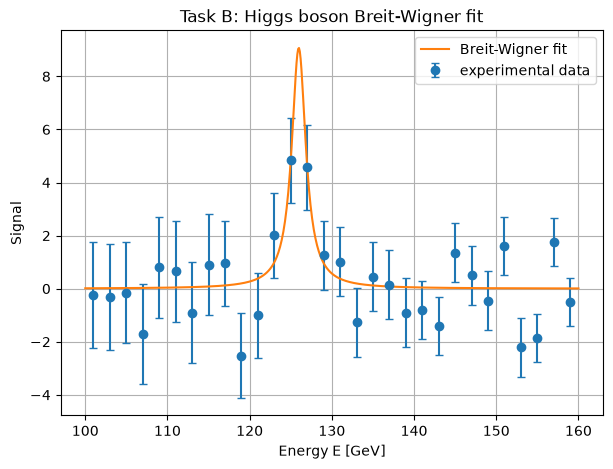

In [9]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("higgs.data.txt")
curve = np.loadtxt("min_B_fit_curve.data")

E = data[:, 0]
signal = data[:, 1]
error = data[:, 2]

plt.figure(figsize=(7, 5))
plt.errorbar(E, signal, yerr=error, fmt="o", capsize=3, label="experimental data")
plt.plot(curve[:, 0], curve[:, 1], label="Breit-Wigner fit")
plt.xlabel("Energy E [GeV]")
plt.ylabel("Signal")
plt.title("Task B: Higgs boson Breit-Wigner fit")
plt.grid(True)
plt.legend()
plt.show()

## Task B conclusion

The Breit-Wigner function was fitted to the Higgs boson data by minimizing the weighted deviation function.

The minimization converged successfully after only a few iterations. The fitted resonance mass was found to be approximately

$$
m = 125.97\ \mathrm{GeV},
$$

which is close to the expected Higgs boson mass. The fitted width was

$$
\Gamma = 2.09\ \mathrm{GeV}.
$$

The fitted curve describes the peak around $E \approx 126\ \mathrm{GeV}$ well. Away from the peak the data fluctuate around zero, which is expected since the background has been subtracted. The fitted width should be interpreted as an experimental width parameter for this dataset, not necessarily as the physical Higgs decay width.

# Task C: Central finite differences

In Task A the numerical derivatives were computed using forward finite differences. In this task the gradient and Hessian are instead computed using central finite differences.

For the gradient, the central approximation is

$$
\frac{\partial f}{\partial x_i}
\approx
\frac{f(x+h_i e_i)-f(x-h_i e_i)}{2h_i}.
$$

For the diagonal Hessian terms,

$$
\frac{\partial^2 f}{\partial x_i^2}
\approx
\frac{f(x+h_i e_i)-2f(x)+f(x-h_i e_i)}{h_i^2}.
$$

For the mixed Hessian terms,

$$
\frac{\partial^2 f}{\partial x_i \partial x_j}
\approx
\frac{
f(x+h_i e_i+h_j e_j)
-f(x+h_i e_i-h_j e_j)
-f(x-h_i e_i+h_j e_j)
+f(x-h_i e_i-h_j e_j)
}{4h_i h_j}.
$$

The two approaches are compared on the Rosenbrock and Himmelblau functions.

In [10]:
from pathlib import Path

Path("min_C.cpp").write_text(r'''
#include <cmath>
#include <functional>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <stdexcept>
#include <string>
#include <vector>

using vec = std::vector<double>;
using matrix = std::vector<std::vector<double>>;
using func = std::function<double(const vec&)>;

vec operator+(const vec& a, const vec& b){
    vec c(a.size());
    for(size_t i=0;i<a.size();i++) c[i]=a[i]+b[i];
    return c;
}

vec operator-(const vec& a, const vec& b){
    vec c(a.size());
    for(size_t i=0;i<a.size();i++) c[i]=a[i]-b[i];
    return c;
}

vec operator*(double s, const vec& a){
    vec c(a.size());
    for(size_t i=0;i<a.size();i++) c[i]=s*a[i];
    return c;
}

double norm(const vec& x){
    double s=0;
    for(double xi : x) s += xi*xi;
    return std::sqrt(s);
}

vec solve_linear(matrix A, vec b){
    const int n = b.size();

    for(int k=0;k<n;k++){
        int pivot = k;
        double best = std::abs(A[k][k]);

        for(int i=k+1;i<n;i++){
            if(std::abs(A[i][k]) > best){
                best = std::abs(A[i][k]);
                pivot = i;
            }
        }

        if(best < 1e-14){
            throw std::runtime_error("singular matrix");
        }

        if(pivot != k){
            std::swap(A[pivot], A[k]);
            std::swap(b[pivot], b[k]);
        }

        for(int i=k+1;i<n;i++){
            double factor = A[i][k]/A[k][k];

            for(int j=k;j<n;j++){
                A[i][j] -= factor*A[k][j];
            }

            b[i] -= factor*b[k];
        }
    }

    vec x(n);

    for(int i=n-1;i>=0;i--){
        double s = b[i];

        for(int j=i+1;j<n;j++){
            s -= A[i][j]*x[j];
        }

        x[i] = s/A[i][i];
    }

    return x;
}

vec gradient_forward(const func& f, const vec& x){
    int n = x.size();
    vec g(n);
    double fx = f(x);

    for(int i=0;i<n;i++){
        double dx = (1 + std::abs(x[i]))*std::pow(2.0,-26);
        vec xp = x;
        xp[i] += dx;
        g[i] = (f(xp)-fx)/dx;
    }

    return g;
}

matrix hessian_forward(const func& f, const vec& x){
    int n = x.size();
    matrix H(n, vec(n));
    vec gx = gradient_forward(f,x);

    for(int j=0;j<n;j++){
        double dx = (1 + std::abs(x[j]))*std::pow(2.0,-13);
        vec xp = x;
        xp[j] += dx;

        vec gp = gradient_forward(f,xp);

        for(int i=0;i<n;i++){
            H[i][j] = (gp[i]-gx[i])/dx;
        }
    }

    // Symmetrize because the Hessian should be symmetric.
    for(int i=0;i<n;i++){
        for(int j=i+1;j<n;j++){
            double hij = 0.5*(H[i][j]+H[j][i]);
            H[i][j] = hij;
            H[j][i] = hij;
        }
    }

    return H;
}

vec gradient_central(const func& f, const vec& x){
    int n = x.size();
    vec g(n);

    for(int i=0;i<n;i++){
        double dx = (1 + std::abs(x[i]))*std::cbrt(2.220446049250313e-16);
        vec xp = x;
        vec xm = x;

        xp[i] += dx;
        xm[i] -= dx;

        g[i] = (f(xp)-f(xm))/(2*dx);
    }

    return g;
}

matrix hessian_central(const func& f, const vec& x){
    int n = x.size();
    matrix H(n, vec(n));
    double fx = f(x);

    std::vector<double> h(n);
    for(int i=0;i<n;i++){
        h[i] = (1 + std::abs(x[i]))*std::cbrt(2.220446049250313e-16);
    }

    for(int i=0;i<n;i++){
        vec xp = x;
        vec xm = x;

        xp[i] += h[i];
        xm[i] -= h[i];

        H[i][i] = (f(xp)-2*fx+f(xm))/(h[i]*h[i]);
    }

    for(int i=0;i<n;i++){
        for(int j=i+1;j<n;j++){
            vec xpp = x;
            vec xpm = x;
            vec xmp = x;
            vec xmm = x;

            xpp[i] += h[i]; xpp[j] += h[j];
            xpm[i] += h[i]; xpm[j] -= h[j];
            xmp[i] -= h[i]; xmp[j] += h[j];
            xmm[i] -= h[i]; xmm[j] -= h[j];

            double value = (f(xpp)-f(xpm)-f(xmp)+f(xmm))/(4*h[i]*h[j]);

            H[i][j] = value;
            H[j][i] = value;
        }
    }

    return H;
}

struct result{
    vec x;
    int iterations;
    int backtracks;
    double fx;
    double grad_norm;
    bool converged;
    std::vector<vec> path;
};

result newton_minimize(const func& f, vec x, bool central, double acc=1e-6, int max_iter=1000){
    result r;
    r.iterations = 0;
    r.backtracks = 0;
    r.converged = false;
    r.path.push_back(x);

    for(int iter=0; iter<max_iter; iter++){
        double fx = f(x);
        vec g = central ? gradient_central(f,x) : gradient_forward(f,x);

        if(norm(g) < acc){
            r.converged = true;
            break;
        }

        matrix H = central ? hessian_central(f,x) : hessian_forward(f,x);

        for(size_t i=0;i<x.size();i++){
            H[i][i] += 1e-6;
        }

        vec minus_g(g.size());
        for(size_t i=0;i<g.size();i++) minus_g[i] = -g[i];

        vec dx;

        try{
            dx = solve_linear(H,minus_g);
        }
        catch(...){
            for(size_t i=0;i<x.size();i++){
                H[i][i] += 1e-3;
            }
            dx = solve_linear(H,minus_g);
        }

        double lambda = 1.0;

        while(lambda > 1.0/1024){
            vec z = x + lambda*dx;

            if(f(z) < fx){
                break;
            }

            lambda /= 2.0;
            r.backtracks++;
        }

        x = x + lambda*dx;
        r.path.push_back(x);
        r.iterations++;

        if(norm(lambda*dx) < 1e-12){
            break;
        }
    }

    r.x = x;
    r.fx = f(x);
    vec gfinal = central ? gradient_central(f,x) : gradient_forward(f,x);
    r.grad_norm = norm(gfinal);

    if(r.grad_norm < acc) r.converged = true;

    return r;
}

double rosenbrock(const vec& x){
    return std::pow(1-x[0],2) + 100*std::pow(x[1]-x[0]*x[0],2);
}

double himmelblau(const vec& x){
    return std::pow(x[0]*x[0]+x[1]-11,2) + std::pow(x[0]+x[1]*x[1]-7,2);
}

void print_result(const std::string& name, const result& r){
    std::cout << name << "\n";
    std::cout << "  x             = ";
    for(double xi : r.x) std::cout << std::setw(16) << xi << " ";
    std::cout << "\n";
    std::cout << "  f(x)          = " << r.fx << "\n";
    std::cout << "  |grad f(x)|   = " << r.grad_norm << "\n";
    std::cout << "  iterations    = " << r.iterations << "\n";
    std::cout << "  backtracks    = " << r.backtracks << "\n";
    std::cout << "  converged     = " << std::boolalpha << r.converged << "\n\n";
}

void write_path(const std::string& filename, const std::vector<vec>& path){
    std::ofstream out(filename);
    out << std::setprecision(17);

    for(const auto& p : path){
        for(double x : p) out << x << " ";
        out << "\n";
    }
}

int main(){
    std::cout << std::setprecision(12);

    std::cout << "Task C: central finite differences\n";
    std::cout << "==================================\n\n";

    result rosen_forward = newton_minimize(rosenbrock, {-1.2,1.0}, false);
    result rosen_central = newton_minimize(rosenbrock, {-1.2,1.0}, true);

    print_result("Rosenbrock, forward differences", rosen_forward);
    print_result("Rosenbrock, central differences", rosen_central);

    std::vector<vec> starts = {
        {2.5,2.0},
        {-3.0,3.0},
        {-4.0,-3.0},
        {4.0,-2.0}
    };

    std::vector<result> hf;
    std::vector<result> hc;

    for(const auto& s : starts){
        hf.push_back(newton_minimize(himmelblau, s, false));
        hc.push_back(newton_minimize(himmelblau, s, true));
    }

    for(size_t i=0;i<starts.size();i++){
        print_result("Himmelblau start " + std::to_string(i+1) + ", forward differences", hf[i]);
        print_result("Himmelblau start " + std::to_string(i+1) + ", central differences", hc[i]);
    }

    write_path("min_C_rosenbrock_forward_path.data", rosen_forward.path);
    write_path("min_C_rosenbrock_central_path.data", rosen_central.path);

    std::ofstream roots("min_C_himmelblau_central_roots.data");
    roots << std::setprecision(17);
    for(const auto& r : hc){
        roots << r.x[0] << " " << r.x[1] << "\n";
    }

    std::ofstream paths("min_C_himmelblau_central_paths.data");
    paths << std::setprecision(17);
    for(const auto& r : hc){
        for(const auto& p : r.path){
            paths << p[0] << " " << p[1] << "\n";
        }
        paths << "\n";
    }

    std::ofstream summary("min_C_summary.data");
    summary << "# method problem index iterations backtracks final_f grad_norm converged\n";

    summary << "forward rosenbrock 0 "
            << rosen_forward.iterations << " "
            << rosen_forward.backtracks << " "
            << rosen_forward.fx << " "
            << rosen_forward.grad_norm << " "
            << rosen_forward.converged << "\n";

    summary << "central rosenbrock 0 "
            << rosen_central.iterations << " "
            << rosen_central.backtracks << " "
            << rosen_central.fx << " "
            << rosen_central.grad_norm << " "
            << rosen_central.converged << "\n";

    for(size_t i=0;i<hf.size();i++){
        summary << "forward himmelblau " << i+1 << " "
                << hf[i].iterations << " "
                << hf[i].backtracks << " "
                << hf[i].fx << " "
                << hf[i].grad_norm << " "
                << hf[i].converged << "\n";

        summary << "central himmelblau " << i+1 << " "
                << hc[i].iterations << " "
                << hc[i].backtracks << " "
                << hc[i].fx << " "
                << hc[i].grad_norm << " "
                << hc[i].converged << "\n";
    }

    std::cout << "Wrote min_C_rosenbrock_forward_path.data\n";
    std::cout << "Wrote min_C_rosenbrock_central_path.data\n";
    std::cout << "Wrote min_C_himmelblau_central_roots.data\n";
    std::cout << "Wrote min_C_himmelblau_central_paths.data\n";
    std::cout << "Wrote min_C_summary.data\n";

    return 0;
}
''')

print("Wrote min_C.cpp")

Wrote min_C.cpp


In [11]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "min_C.cpp",
    "-o",
    "min_C"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./min_C"], text=True, capture_output=True, timeout=30)

    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task C: central finite differences

Rosenbrock, forward differences
  x             =   0.999990917933   0.999981821203 
  f(x)          = 8.25056875327e-11
  |grad f(x)|   = 3.17507704028e-07
  iterations    = 23
  backtracks    = 6
  converged     = true

Rosenbrock, central differences
  x             =   0.999999970609   0.999999941216 
  f(x)          = 8.63849462249e-16
  |grad f(x)|   = 3.93520651435e-10
  iterations    = 21
  backtracks    = 7
  converged     = true

Himmelblau start 1, forward differences
  x             =    2.99999997181    1.99999999421 
  f(x)          = 3.32504861109e-14
  |grad f(x)|   = 3.21634218542e-09
  iterations    = 5
  backtracks    = 0
  converged     = true

Himmelblau start 1, central differences
  x             =    2.99999999991    1.99999999997 
  f(x)          = 3.44394879631e-19
  |grad f(x)|   = 2.32709510333e-13
  iterations    = 5
  backtracks    = 0
  converged     = true

Himmelblau start 2, forward

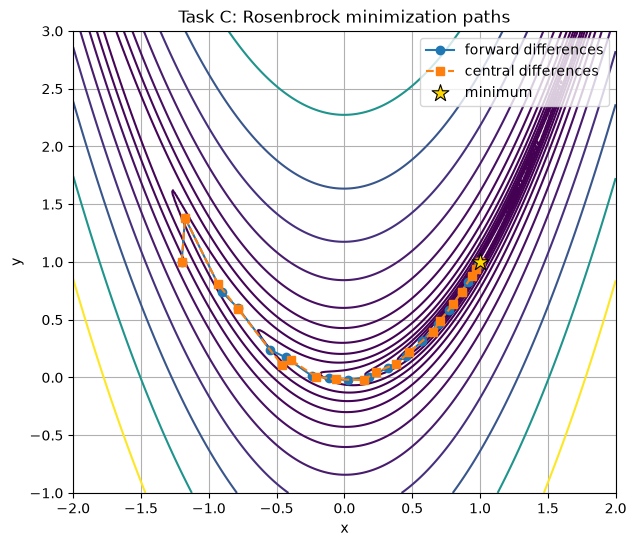

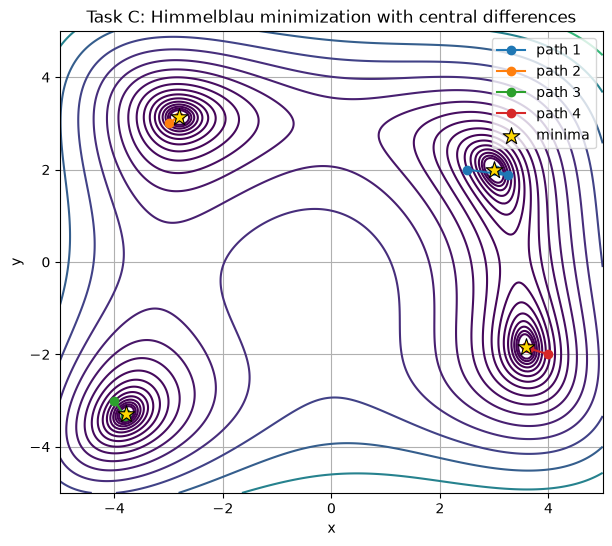

/tmp/ipykernel_66821/982782324.py:76: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  summary = np.loadtxt("min_C_summary.data", dtype=str, comments="#")


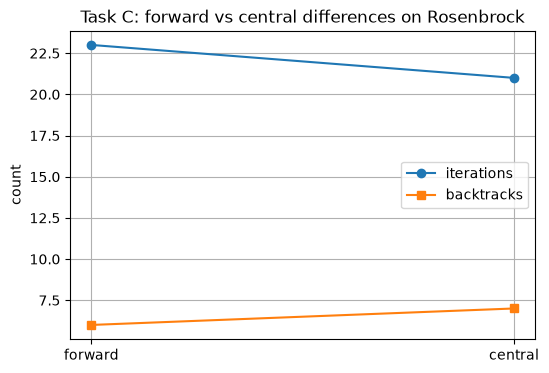

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- Rosenbrock comparison ----------
rosen_forward = np.loadtxt("min_C_rosenbrock_forward_path.data")
rosen_central = np.loadtxt("min_C_rosenbrock_central_path.data")

x = np.linspace(-2.0, 2.0, 300)
y = np.linspace(-1.0, 3.0, 300)
X, Y = np.meshgrid(x, y)
Z = (1 - X)**2 + 100*(Y - X**2)**2

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 15))
plt.plot(rosen_forward[:, 0], rosen_forward[:, 1], marker="o", label="forward differences")
plt.plot(rosen_central[:, 0], rosen_central[:, 1], marker="s", linestyle="--", label="central differences")
plt.scatter([1], [1], marker="*", s=160, color="gold", edgecolor="black", linewidths=0.8, label="minimum", zorder=5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Task C: Rosenbrock minimization paths")
plt.legend()
plt.grid(True)
plt.show()


# ---------- Himmelblau central paths ----------
himmel_roots = np.loadtxt("min_C_himmelblau_central_roots.data")

x = np.linspace(-5.0, 5.0, 400)
y = np.linspace(-5.0, 5.0, 400)
X, Y = np.meshgrid(x, y)
Z = (X**2 + Y - 11)**2 + (X + Y**2 - 7)**2

blocks = []
current = []

for line in Path("min_C_himmelblau_central_paths.data").read_text().splitlines():
    if line.strip():
        current.append([float(v) for v in line.split()])
    else:
        if current:
            blocks.append(np.array(current))
            current = []

if current:
    blocks.append(np.array(current))

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=np.logspace(0, 3, 18))

for i, block in enumerate(blocks):
    plt.plot(block[:, 0], block[:, 1], marker="o", label=f"path {i+1}")

plt.scatter(
    himmel_roots[:, 0],
    himmel_roots[:, 1],
    marker="*",
    s=160,
    color="gold",
    edgecolor="black",
    linewidths=0.8,
    label="minima",
    zorder=5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Task C: Himmelblau minimization with central differences")
plt.legend()
plt.grid(True)
plt.show()


# ---------- Summary comparison ----------
summary = np.loadtxt("min_C_summary.data", dtype=str, comments="#")

labels = []
iterations = []
backtracks = []

for row in summary:
    method, problem, index, it, bt, fx, gn, conv = row
    if problem == "rosenbrock":
        labels.append(method)
        iterations.append(int(it))
        backtracks.append(int(bt))

xpos = np.arange(len(labels))

plt.figure(figsize=(6, 4))
plt.plot(xpos, iterations, marker="o", label="iterations")
plt.plot(xpos, backtracks, marker="s", label="backtracks")
plt.xticks(xpos, labels)
plt.ylabel("count")
plt.title("Task C: forward vs central differences on Rosenbrock")
plt.grid(True)
plt.legend()
plt.show()

## Task C conclusion

Central finite differences were implemented for both the numerical gradient and the numerical Hessian matrix. The method was compared with the forward finite-difference version from Task A.

For the Rosenbrock function, both methods converged to the expected minimum near

$$
(x,y)=(1,1).
$$

The forward-difference method used 23 Newton iterations and reached

$$
f(x) \approx 8.25\cdot 10^{-11},
$$

whereas the central-difference method used 21 Newton iterations and reached

$$
f(x) \approx 8.64\cdot 10^{-16}.
$$

Thus, the central-difference method gave a much more accurate final result and required slightly fewer Newton iterations, although it used one more backtracking step.

For the Himmelblau function, the central-difference method successfully converged to the four expected minima from different starting points. The plotted paths show that the algorithm moves toward the nearby local minimum in each case.

Overall, central finite differences are more accurate than forward finite differences, but they require more function evaluations. In this problem the improved accuracy was worth the extra computational cost.